In [1]:
from functools import partial

import matplotlib.pyplot as plt

from superfv import HydroSolver
import superfv.initial_conditions as superic
from spd.spectral_difference.sd_simulator import SD_Simulator
import spd.initial_conditions as spdic

In [2]:
NDOF = 128
p = 3
T = 1.0

In [3]:
super_sim = HydroSolver(
    ic=partial(superic.square, vx=1.0),
    nx=NDOF,
    p=p,
    gamma=1.4,
)
super_sim.run(T)

SuperFV: 357 steps | t=1.00e+00/1.00e+00, dt=1.97e-03 | rho_min=9.28e-01 | E_cons=0.00e+00 | wall=1.94e-01s (done)


In [4]:
N = NDOF // (p + 1)

spd_sim = SD_Simulator(
    p=3,
    N=(N,),
    init_fct=spdic.step_function(),
    cfl_coeff=0.6,
    use_cupy=True,
    time_integrator="rk3",
    gamma=1.4,
    riemann_solver="hllc",
)
spd_sim.perform_time_evolution(T)

t=1.0, steps taken 477, time taken 0.12, bzcps = 0.001


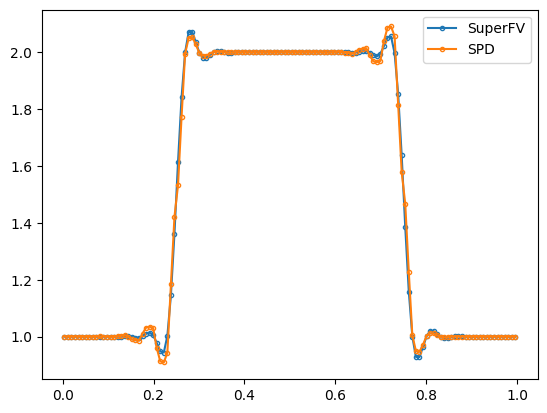

In [5]:
plt.plot(
    super_sim.mesh.x_centers,
    super_sim.snapshot_history[-1].u[super_sim.idx("rho"), :, 0, 0],
    label="SuperFV",
    linestyle="-",
    marker=".",
    mfc="none",
)
plt.plot(
    super_sim.mesh.x_centers,
    spd_sim.transpose_to_fv(spd_sim.dm.W_cv)[0, ...],
    label="SPD",
    linestyle="-",
    marker=".",
    mfc="none",
)
plt.legend()